In [1]:
# Official packages
import os
import copy
import math
import re
import time

from pprint import pprint
from itertools import chain

# Third-party packages
import numpy as np
import scipy

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm


import pyopencl as cl
for item in cl.get_platforms():
    print(item.get_devices())

import pynufft
device_list = pynufft.helper.device_list()
for item in device_list:
    print(item)
    
# In-house packages
from BrukerPV360 import BrukerPV360Exp


def normalize_array(arr:np.array):
    return arr/np.max(arr)

C:\Anaconda3\lib\site-packages\pytools\persistent_dict.py:59: UserWarning: pytools.persistent_dict: unable to import 'siphash24.siphash13', falling back to hashlib.sha256
  warn("pytools.persistent_dict: unable to import 'siphash24.siphash13', "


[<pyopencl.Device 'Intel(R) UHD Graphics' on 'Intel(R) OpenCL Graphics' at 0x2f3944a0e40>]
[<pyopencl.Device '11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz' on 'Intel(R) OpenCL' at 0x2f39244cbe0>]
[<pyopencl.Device 'Intel(R) FPGA Emulation Device' on 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x2f39244bf60>]
[]
No cuda device found. Check your pycuda installation.
('ocl', 0, 0, <pyopencl.Platform 'Intel(R) OpenCL Graphics' at 0x2f38d7c65d0>, <pyopencl.Device 'Intel(R) UHD Graphics' on 'Intel(R) OpenCL Graphics' at 0x2f3944a0e40>, <reikna.cluda.ocl.Thread object at 0x000002F3941648E0>, 64)
('ocl', 1, 0, <pyopencl.Platform 'Intel(R) OpenCL' at 0x2f3943758c0>, <pyopencl.Device '11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz' on 'Intel(R) OpenCL' at 0x2f39244cbe0>, <reikna.cluda.ocl.Thread object at 0x000002F395E772B0>, 1)
('ocl', 2, 0, <pyopencl.Platform 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x2f394374a80>, <pyopencl.Device 'Intel(R) FPGA Emulation Device' on 'In

<function matplotlib.pyplot.show(close=None, block=None)>

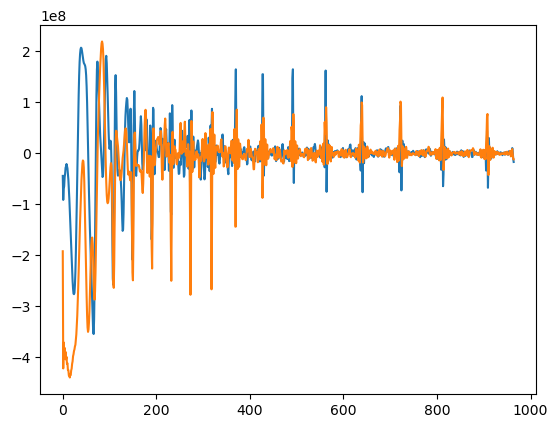

In [2]:
raw_path = "TestData/BrukerPV360/Spiral2d1Intlv"

a = BrukerPV360Exp(raw_path, is_verbose=False)

FID = a.dataset['DATA']['rawdata'][0]
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show

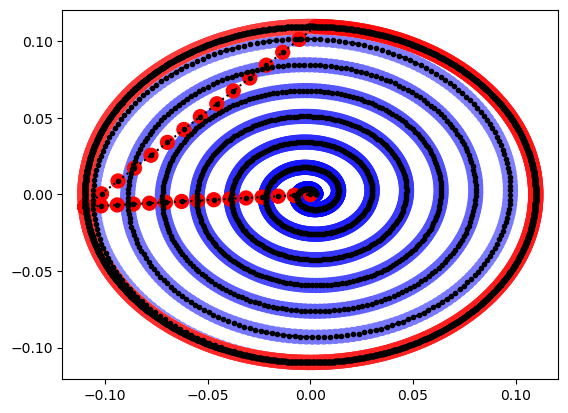

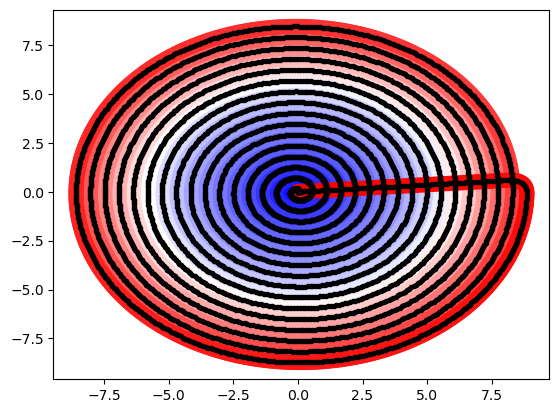

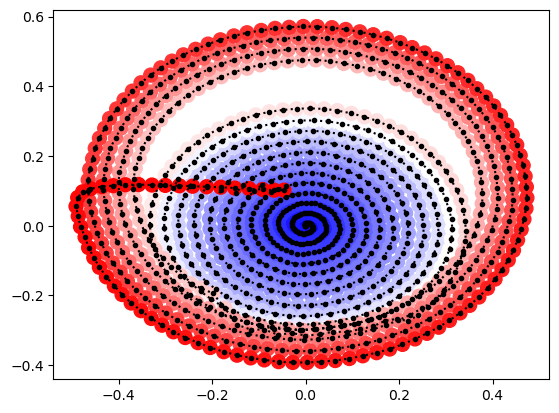

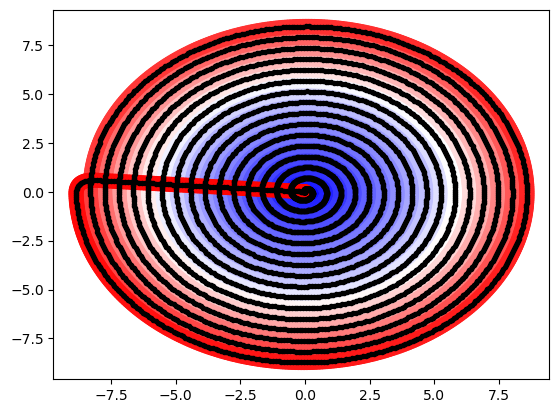

In [3]:
spiral_x = (a.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_y = (a.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])
 
plt.figure()
plt.scatter(spiral_x, spiral_y, c=(range(len(spiral_x))), s=100, cmap='bwr')
plt.plot(spiral_x, spiral_y, c= "black", marker='.', linestyle=':')
plt.show()

traj_cal_x = np.cumsum(spiral_x)
traj_cal_y = np.cumsum(spiral_y)

plt.figure()
plt.scatter(traj_cal_x, traj_cal_y, c=(range(len(traj_cal_y))), s=100, cmap='bwr')
plt.plot(traj_cal_x, traj_cal_y, c= "black", marker='.', linestyle=':')
plt.show()

traj_kx = (a.dataset['PARAM']['method'][0]['PVM_TrajKx'])
traj_ky = (a.dataset['PARAM']['method'][0]['PVM_TrajKy'])

plt.figure()
plt.scatter(traj_kx, traj_ky, c=(range(len(traj_kx))), s=100, cmap='bwr')
plt.plot(traj_kx, traj_ky, c= "black", marker='.', linestyle=':')
plt.show()


plt.figure()
plt.scatter(-traj_cal_x, traj_cal_y, c=(range(len(traj_cal_y))), s=100, cmap='bwr')
plt.plot(-traj_cal_x, traj_cal_y, c= "black", marker='.', linestyle=':')
plt.show()

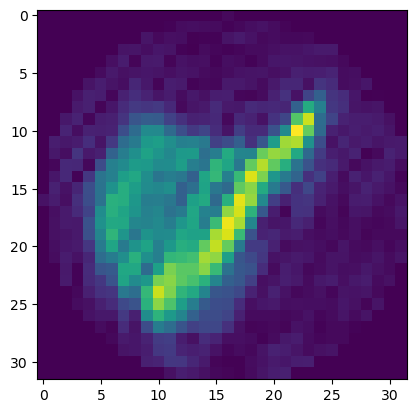

In [4]:
bruker_data = a.dataset['DATA']['2dseq']

shape = [int(x) for x in a.dataset['PARAM']['method'][0]['PVM_Matrix']]

bruker_data = np.reshape(bruker_data, shape)

plt.imshow(bruker_data)
plt.show()

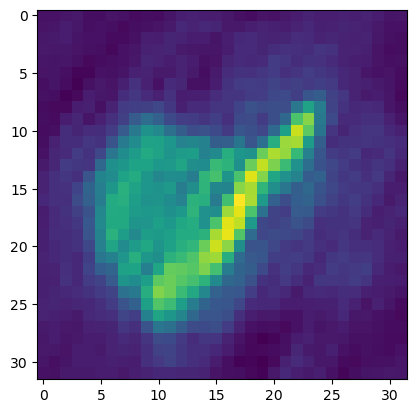

965


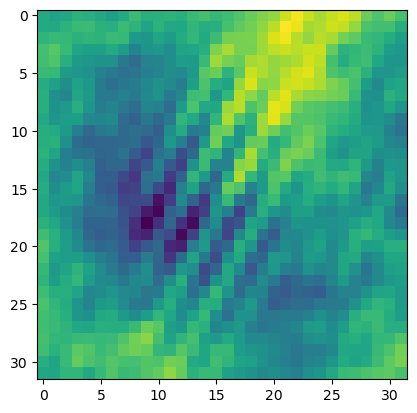

In [5]:
spiral_traj_cal = np.asarray(list(zip(traj_cal_x,traj_cal_y)))[::5]

Nd = (32, 32)  # image size
Kd = (128, 128)  # k-space size
Jd = (16, 16)  # interpolation size

spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal, Nd, Kd, Jd)

y_cal = spiralObj.forward(bruker_data)
recon = spiralObj.solve(y_cal, solver='cg', maxiter=50)
plt.figure()
plt.imshow(recon.real, cmap=cm.viridis)
plt.show()

print(len(spiral_traj_cal))

plt.figure()
plt.imshow(np.real(spiralObj.solve(y_cal, solver='lsmr', maxiter=50)-spiralObj.solve(y_cal, solver='cg', maxiter=50)), cmap=cm.viridis)
plt.show()

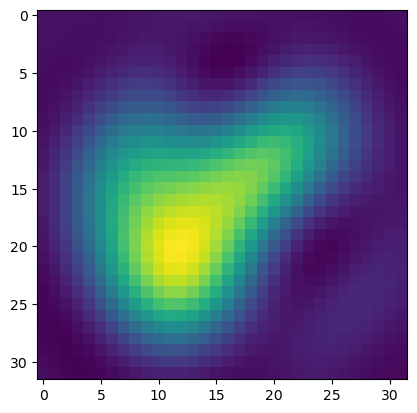

In [6]:
spiral_traj_bruker = np.asarray(list(zip(traj_kx, traj_ky)))

Nd = (32, 32)  # image size
Kd = (128, 128)  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_bruker, Nd, Kd, Jd)

y_bruker = spiralObj.forward(bruker_data)
recon = spiralObj.solve(y_bruker, solver='lgmres', maxiter=500)
plt.figure()
plt.imshow(recon.real, cmap=cm.viridis)
plt.show()

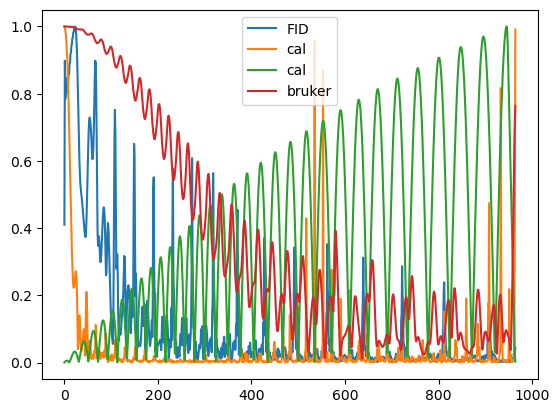

In [12]:
plt.figure()
plt.plot(normalize_array(np.abs(FID)), label='FID')
plt.plot(normalize_array(np.abs(y_cal)), label='cal')
plt.plot(normalize_array(np.abs(traj_cal_x[::5])), label='cal')
plt.plot(normalize_array(np.abs(y_bruker )), label='bruker')
plt.legend()
plt.show()

(1890,)
(1890,)
(1890,)


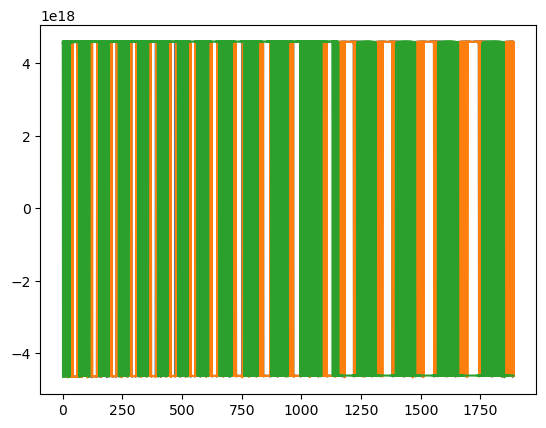

In [8]:
traj_path = os.path.join(raw_path, 'traj')

raw_traj = np.fromfile(file=traj_path, dtype='int64')

print(np.shape(raw_traj))
plt.plot(raw_traj[:])

traj_path = os.path.join(raw_path, 'trajDC')

raw_traj = np.fromfile(file=traj_path, dtype='int64')

print(np.shape(raw_traj))
plt.plot(raw_traj[:])


traj_path = os.path.join(raw_path, 'b0')

raw_traj = np.fromfile(file=traj_path, dtype='int64')

print(np.shape(raw_traj))
plt.plot(raw_traj[:])

In [9]:
print(len(y_bruker),len(FID))

965 965
